### T5 трансформер для перевода с немецкого на английский

В этом задании вам предстоит обучить encoder-decoder трансформер переводить короткие предложения с немецкого на английский.

Токенизацию и блоки трансформера писать не придётся — будем пользоваться библиотекой `transformers`.

Наши задачи:
- Познакомиться с наиболее популярным методом токенизации текстов — byte pair encoding
- Научиться пользоваться токенизатором из `transformers`
- Подготовить данные
- Обучить готовую архитектуру T5-small под нашу задачу
- Исследовать разные стратегии декодирования с помощью обученной модели

In [1]:
import math
from pathlib import Path
from typing import cast

import lightning as L
import torch
import torch.nn.functional as F
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from transformers import T5ForConditionalGeneration, T5Tokenizer

from datasets import load_dataset, load_from_disk

In [2]:
torch.manual_seed(42)

#### Готовим данные

In [3]:
train_dataset = load_dataset("bentrevett/multi30k", split="train")
test_dataset = load_dataset("bentrevett/multi30k", split="test")

In [4]:
train_dataset[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

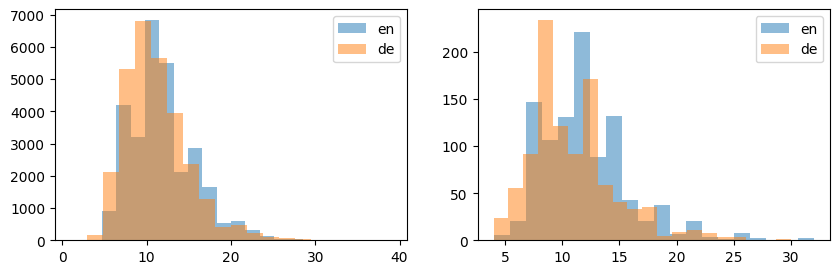

In [5]:
import matplotlib.pyplot as plt


def length_histogram(dataset, ax, bins=20) -> None:
    en_lengths = []
    de_lengths = []
    for sample in dataset:
        en_lengths.append(len(sample["en"].split(" ")))
        de_lengths.append(len(sample["de"].split(" ")))

    ax.hist(en_lengths, alpha=0.5, bins=bins, label="en")
    ax.hist(de_lengths, alpha=0.5, bins=bins, label="de")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(10, 3))
length_histogram(train_dataset, axes[0])
length_histogram(test_dataset, axes[1])

Оставим только сравнительно короткие предложения, чтобы можно было чему-то научиться за короткое время

In [6]:
maxlen = 8


def filter_dataset(dataset, maxlen: int) -> list[dict[str, str]]:
    return [
        dataset[i]
        for i in range(len(dataset))
        if len(dataset[i]["en"].split(" ")) <= maxlen
    ]


train_filtered = filter_dataset(train_dataset, maxlen)
test_filtered = filter_dataset(test_dataset, maxlen)

print(len(train_filtered), len(test_filtered))

5144 174


##### Токенизация: byte-pair encoding

Построение:

Начинаем со словаря, состоящего из отдельных символов (начальные токены).
На каждом шаге:
1. Оцениваем частоту всех пар токенов внутри слов, находим самую частую
2. Добавляем её в список токенов и в таблицу слияний
3. Останавливаемся, когда достигаем максимального размера словаря


Применение:

1. Разбиваем текст на символы
2. Находим первое возможное слияние в таблице и применяем его
3. Останавливаемся, когда дальнейшие слияния невозможны

<img src="https://lena-voita.github.io/resources/lectures/seq2seq/bpe/build_merge_table.gif" style="background:white" width="720"/>
<img src="https://lena-voita.github.io/resources/lectures/seq2seq/bpe/bpe_apply.gif" style="background:white" width="270"/>

Реализаций много, мы будем использовать токенизатор  из библиотеки `transformers`, где помимо самого подготовленного токенизатора (`sentencepiece.SentencePieceProcessor`) много полезных методов для кодирования и декодирования.

Добавим при создании новый токен, который будет указывать на начало перевода

In [7]:
tokenizer: T5Tokenizer = T5Tokenizer.from_pretrained(
    "t5-small", padding_size="right", bos_token="</b>", legacy=False
)

In [10]:
print("Размер словаря: ", len(tokenizer))

Размер словаря:  32101


Посмотрим на примеры токенов, в них встречаются и целые слова из разных языков, и числительные, и знаки препинания:

In [11]:
import random

random.choices(list(tokenizer.get_vocab().items()), k=10)

[('▁réserve', 13330),
 ('▁breathing', 10882),
 ('▁insist', 10419),
 ('öfte', 29863),
 ('fusion', 7316),
 ('tiri', 20408),
 ('▁schools', 2061),
 ('pens', 3801),
 ('damals', 18866),
 ('Performing', 26656)]

Токенизатор в работе: кодирование и декодирование предложений на немецком и английском:

In [12]:
encoded_german = tokenizer.encode(train_dataset[0]["de"])
encoded_english = tokenizer.encode(train_dataset[0]["en"])
print(encoded_german)
print(tokenizer.decode(encoded_german))
print(encoded_english)
print(tokenizer.decode(encoded_english))

[11280, 16815, 7838, 15, 16282, 436, 256, 8671, 35, 16, 74, 13271, 2221, 49, 21162, 3992, 5, 1]
Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.</s>
[2759, 1021, 6, 1945, 5069, 7, 33, 1067, 1084, 186, 3, 30271, 5, 1]
Two young, White males are outside near many bushes.</s>


Об упаковке в батчи можно больше не беспокоиться — токенизатор умеет обрабатывать сразу пачку примеров

In [13]:
batch = [train_dataset[i]["en"] for i in range(4)]

encoded_batch = tokenizer.batch_encode_plus(
    batch, padding="longest", return_tensors="pt"
)
print(encoded_batch["input_ids"].shape)
print(encoded_batch.keys())

torch.Size([4, 19])
KeysView({'input_ids': tensor([[ 2759,  1021,     6,  1945,  5069,     7,    33,  1067,  1084,   186,
             3, 30271,     5,     1,     0,     0,     0,     0,     0],
        [    3,  8656,  1076,    16,   614,     3,   547,     7,    33,  2699,
             3,     9,  6079,  3197,    15,    63,   358,     5,     1],
        [   71,   385,  3202, 11908,   139,     3,     9,  5726,   577,  1840,
             5,     1,     0,     0,     0,     0,     0,     0,     0],
        [   71,   388,    16,     3,     9,  1692,  8677,    19,  4125,    30,
             3,     9, 15812,  2327,     3,     9,  2034,     5,     1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])})


Возвращается два значения: `input_ids` — это наши токены, а `attention_mask` — это тензор, равный по размеру батчу токенов, где на месте `pad_token` стоят нули, в остальных позициях — единицы. Это нам понадобится потом.

А ещё можно кодировать сразу входные и выходные данные:

In [14]:
inputs = [train_dataset[i]["de"] for i in range(4)]
targets = [tokenizer.bos_token + train_dataset[i]["en"] for i in range(4)]

encoded_batch = tokenizer(
    inputs, text_target=targets, padding="longest", return_tensors="pt"
)
print(encoded_batch.keys())

KeysView({'input_ids': tensor([[11280, 16815,  7838,    15, 16282,   436,   256,  8671,    35,    16,
            74, 13271,  2221,    49, 21162,  3992,     5,     1,     0,     0,
             0,     0],
        [11093,    49,    15, 16282,   181, 10956, 17757,    35,  1953,    23,
            35,    35,   236,   389, 13835,     7,  5672,  3734,     5,     1,
             0,     0],
        [  890,  5683,     7, 21644,     3,   157, 16024,    17,    16,   236,
          3012,  2989,   403,  8589,     5,     1,     0,     0,     0,     0,
             0,     0],
        [  890,  6362,    16,   665,     3, 16193,    35,   216,    51,    26,
          4186,   219,   645, 24484,    64,   474,   172,    17,   236, 16814,
             5,     1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 

Используем это в `collate_fn` для сборки батчей:

In [15]:
def collate_fn(
    tokenizer: T5Tokenizer, batch: list[tuple[str, str]]
) -> tuple[Tensor, Tensor]:
    prompt = tokenizer.bos_token
    inputs, targets = zip(*[(pair["de"], prompt + pair["en"]) for pair in batch])
    encoded_batch = tokenizer(
        inputs, text_target=targets, padding="longest", return_tensors="pt"
    )
    return encoded_batch

In [16]:
batch = [train_dataset[i] for i in range(4)]
encoded_batch = collate_fn(tokenizer, batch)
print(encoded_batch.keys())

KeysView({'input_ids': tensor([[11280, 16815,  7838,    15, 16282,   436,   256,  8671,    35,    16,
            74, 13271,  2221,    49, 21162,  3992,     5,     1,     0,     0,
             0,     0],
        [11093,    49,    15, 16282,   181, 10956, 17757,    35,  1953,    23,
            35,    35,   236,   389, 13835,     7,  5672,  3734,     5,     1,
             0,     0],
        [  890,  5683,     7, 21644,     3,   157, 16024,    17,    16,   236,
          3012,  2989,   403,  8589,     5,     1,     0,     0,     0,     0,
             0,     0],
        [  890,  6362,    16,   665,     3, 16193,    35,   216,    51,    26,
          4186,   219,   645, 24484,    64,   474,   172,    17,   236, 16814,
             5,     1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 

In [17]:
print(encoded_batch["input_ids"].shape)
print(encoded_batch["attention_mask"].shape)
print(encoded_batch["labels"].shape)

torch.Size([4, 22])
torch.Size([4, 22])
torch.Size([4, 20])


Всё готово для получения минибатчей из датасетов:

In [18]:
train_loader = DataLoader(
    train_filtered,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda batch: collate_fn(tokenizer, batch),
)
test_loader = DataLoader(
    test_filtered,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda batch: collate_fn(tokenizer, batch),
)

#### Задание 1 (2 балла). DataModule

Реализуйте подкласс `lightning.LightningDataModule` для работы с обучающим и тестовым датасетами

In [19]:
from lightning.pytorch.utilities.types import EVAL_DATALOADERS, TRAIN_DATALOADERS
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import torch
from torch import Tensor


class Multi30kDataset(L.LightningDataModule):
    train_dataset: Dataset
    test_dataset: Dataset
    tokenizer: T5Tokenizer

    def __init__(self, train_data: list[dict[str, str]], test_data: list[dict[str, str]], maxlen: int = 128, batch_size: int = 32) -> None:
        super().__init__()
        self.tokenizer = T5Tokenizer.from_pretrained("t5-small")
        self.train_data = train_data
        self.test_data = test_data
        self.maxlen = maxlen
        self.batch_size = batch_size
        self.train_dataset = None
        self.test_dataset = None

    def setup(self, stage: str = None) -> None:
        if stage in ("fit", "validate"):
            self.train_dataset = TokenizedDataset(self.train_data, self.tokenizer, self.maxlen)
        if stage in ("test", "predict"):
            self.test_dataset = TokenizedDataset(self.test_data, self.tokenizer, self.maxlen)

    def train_dataloader(self) -> TRAIN_DATALOADERS:
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=self.collate_fn,
        )

    def test_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

    @staticmethod
    def collate_fn(batch: list[dict[str, Tensor]]) -> dict[str, Tensor]:
        input_ids = [item["input_ids"] for item in batch]
        attention_mask = [item["attention_mask"] for item in batch]
        labels = [item["labels"] for item in batch]
        input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
        attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
        labels = pad_sequence(labels, batch_first=True, padding_value=-100)
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }


class TokenizedDataset(Dataset):
    def __init__(self, data: list[dict[str, str]], tokenizer: T5Tokenizer, maxlen: int):
        self.data = data
        self.tokenizer = tokenizer
        self.maxlen = maxlen

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> dict[str, Tensor]:
        item = self.data[idx]
        input_text = f"translate German to English: {item['de']}"
        label_text = item['en']
        input_encoding = self.tokenizer(
            input_text,
            max_length=self.maxlen,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        label_encoding = self.tokenizer(
            label_text,
            max_length=self.maxlen,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        labels = label_encoding["input_ids"].clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            "input_ids": input_encoding["input_ids"].squeeze(0),
            "attention_mask": input_encoding["attention_mask"].squeeze(0),
            "labels": labels.squeeze(0),
        }

In [22]:
multi30k = Multi30kDataset(train_dataset, test_dataset, maxlen=128, batch_size=8)
multi30k.setup("fit")
batch = next(iter(multi30k.train_dataloader()))
print(batch["input_ids"].shape)

torch.Size([8, 128])


#### Задание 2 (4 балла). Обучение T5

paper: https://arxiv.org/abs/1910.10683

Обучите `t5-small` на наших данных, длительность обучения — на ваше усмотрение. В [документации](https://huggingface.co/docs/transformers/model_doc/t5) вы найдёте примеры использования, которые помогут вам разобраться в интерфейсе модели.

In [23]:
t5 = T5ForConditionalGeneration.from_pretrained("t5-small")

Обернём в `LightningModule`

In [24]:
import lightning as L
from lightning.pytorch.utilities.types import STEP_OUTPUT, OptimizerLRScheduler
from torch.optim import AdamW

class Seq2Seq(L.LightningModule):
    def __init__(
        self,
        model: nn.Module,
        tokenizer: T5Tokenizer,
        lr: float = 0.001,
    ) -> None:
        super().__init__()
        self.model = model
        self.tokenizer = tokenizer
        self.lr = lr
        self.save_hyperparameters(ignore=["model", "tokenizer"])
        
    def forward(self, input_ids: Tensor, attention_mask: Tensor, labels: Tensor = None):
        return self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

    def training_step(self, batch: dict[str, Tensor], batch_idx: int) -> STEP_OUTPUT:
        outputs = self.forward(
            batch["input_ids"],
            batch["attention_mask"],
            batch["labels"]
        )
        loss = outputs.loss
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self) -> OptimizerLRScheduler:
        return AdamW(self.model.parameters(), lr=self.lr)

In [25]:
t5 = T5ForConditionalGeneration.from_pretrained("t5-small")
multi30k = Multi30kDataset(train_dataset, test_dataset, batch_size=8)
multi30k.setup("fit")

In [26]:
trainer = L.Trainer(
    accelerator="auto", max_epochs=1, limit_train_batches=10, logger=False
)
seq2seq = Seq2Seq(t5, multi30k.tokenizer, lr=0.001)
trainer.fit(model=seq2seq, train_dataloaders=multi30k.train_dataloader())

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/Deep-Learning-2025-MCS/.venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:701: Checkpoint directory /home/Deep-Learning-2025-MCS/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                       | Params | Mode
--

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


#### Задание 3 (2 балла). Генерация перевода

Сгенерируйте перевод для одного батча из тестового датасета (используйте метод `t5.generate()`), используя разные стратегии декодирования:
- *greedy decoding*
- *multinomial sampling*
- *beam-search multinomial sampling*

Эти стратегии (а также другие стратегии декодирования) можно задавать через `transformers.GenerationConfig`, который можно передать в метод `.generate()` нашей модели.
Выберите параметры, которые, на ваш взгляд, работают лучше всего.

In [27]:
from transformers import GenerationConfig

# пример конфигурации
gen_conf = GenerationConfig(
    min_length=10,
    max_new_tokens=20,
    num_beams=4,
    do_sample=True,
    temperature=1.0,
    top_p=0.9,
)

In [28]:
multi30k.setup("test")

batch = next(iter(multi30k.test_dataloader()))
device = next(t5.parameters()).device
batch = {k: v.to(device) for k, v in batch.items()}
preds = t5.generate(batch["input_ids"], generation_config=gen_conf)

# декодируем входы, правильный и сгенерированный перевод с помощью токенизатора и выводим
for i in range(min(12, len(batch["input_ids"]))):
    de_text = multi30k.tokenizer.decode(batch["input_ids"][i], skip_special_tokens=True).replace("translate German to English: ", "")
    labels = batch["labels"][i].clone()
    labels[labels == -100] = multi30k.tokenizer.pad_token_id
    en_true = multi30k.tokenizer.decode(labels, skip_special_tokens=True)
    trans = multi30k.tokenizer.decode(preds[i], skip_special_tokens=True)
    
    print(f"Deutsch: {de_text}")
    print(f"English: {en_true}")
    print(f"Translation: {trans}")
    print()

Deutsch: Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
English: A man in an orange hat starring at something.
Translation: A man with a white shirt, a little starry.

Deutsch: Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
English: A Boston Terrier is running on lush green grass in front of a white fence.
Translation: A Boston Terrier is running over saftig-grün grass in front of a

Deutsch: Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.
English: A girl in karate uniform breaking a stick with a front kick.
Translation: A girl in a car with a trunk.

Deutsch: Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.
English: Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.
Translation: Five people in jacking and with helmets standing in snow with snowmobilers in the background

Deutsch: Leute Reparieren das Dach eines Hauses.
English: People a